In [2]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt 
plt.style.use(['seaborn-v0_8-paper'])


# Atividade

# Aplique o método de estimação de parâmetros via o algoritimo de gradiente descendente e compare a solução encontrada pelo método dos mínimos quadrados. 
# Discuta os resultados encontrados
# ============================================================================================


# defining functions 
def predict(X, theta):
    """Make predictions using linear model: ŷ = Xθ"""
    return np.dot(X, theta)

def calculate_residual(X_sample, theta, y_actual):
    """Calculate residual (error) for a single data point: y_hat - y_actual"""
    return np.dot(X_sample, theta) - y_actual

def least_squares(X, y):
    """Normal equation: θ = (XᵀX)⁻¹Xᵀy"""
    return np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, y))

def gradient_descent(X, y, initial_theta, learning_rate, epochs):
    """
    Perform gradient descent to optimize linear regression parameters.
    
    Parameters:
    -----------
    X : numpy.ndarray, shape (n_samples, n_columns)     | Feature matrix with lineaar coef term 
    y : numpy.ndarray, shape (n_samples, 1)             | Target values
    initial_theta : numpy.ndarray, shape (n_columns, 1) | Initial parameter guess
    learning_rate : float                               | Step size for parameter updates
    n_epochs : int                                      | Number of training iterations
        
    Returns:
    --------
    theta_optimized : numpy.ndarray                     | Optimized parameters
    errors : numpy.ndarray                              | Sum of squared errors per epoch
    """
    theta_current = initial_theta.copy()
    errors = np.zeros(epochs)
    
    for epoch in range(epochs):
        total_squared_error = 0.0

        for i in range(len(X)):
            # Calculate error for current data point
            residual = calculate_residual(X[[i], :], theta_current, y[i])
            
            residual_scalar = residual.item() # como o dado é 1D precisa pegar no formato do valor ao inves da matrix
            
            gradient = 2 * residual_scalar * X[[i], :].T
            theta_current = theta_current - (learning_rate * gradient)
            
            total_squared_error += residual_scalar**2

        # Store error (both are scalars now)
        errors[epoch] = total_squared_error
    
    # print(theta_current)    
    return theta_current, errors




# Importing dataset
path = kagglehub.dataset_download("andonians/random-linear-regression")

# Load and clean training data 
data_train =  pd.read_csv(f"{path}/train.csv") 
train_valids = data_train.dropna(subset=['x', 'y']) # Remove any row with NaN in either column pd.dropna
x_train = train_valids['x'].to_numpy(dtype=float).reshape(-1, 1)
y_train = train_valids['y'].to_numpy(dtype=float).reshape(-1, 1)

# Load test data
data_test = pd.read_csv(f"{path}/test.csv")
x_test = data_test['x'].to_numpy(dtype=float).reshape(-1, 1)
y_test = data_test['y'].to_numpy(dtype=float).reshape(-1, 1)

# MMQ - Metodo dos minimos quadrados
mq_params = least_squares(x_train, y_train)
mmq_pred = predict(x_test, mq_params)

# GD -  Gradiente Descendente 
guess = [3.1] 
alpha = 1e-8
epochs = 300
gd_params, epoch_errors = gradient_descent(x_test, y_test, guess, alpha, epochs)
gd_pred = predict(x_test, gd_params)

# Resultados
print("=== PARÂMETROS ===")
print(f"Mínimos Quadrados: {mq_params[0][0]:.6f}")
print(f"Gradiente Descendente: {gd_params[0][0]:.6f}")

# Analise de MSE
mse_mmq = np.mean((mmq_pred - y_test) ** 2) 
mse_gd = np.mean((gd_pred - y_test) ** 2)
print(f"MSE Mínimos Quadrados: {mse_mmq:.6f}")
print(f"MSE Gradiente Descendente: {mse_gd:.6f}")


# linestyle supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

d:\Codigos_VSCode\ENGG21\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== PARÂMETROS ===
Mínimos Quadrados: 0.999049
Gradiente Descendente: 1.011982
MSE Mínimos Quadrados: 9.453864
MSE Gradiente Descendente: 9.285707


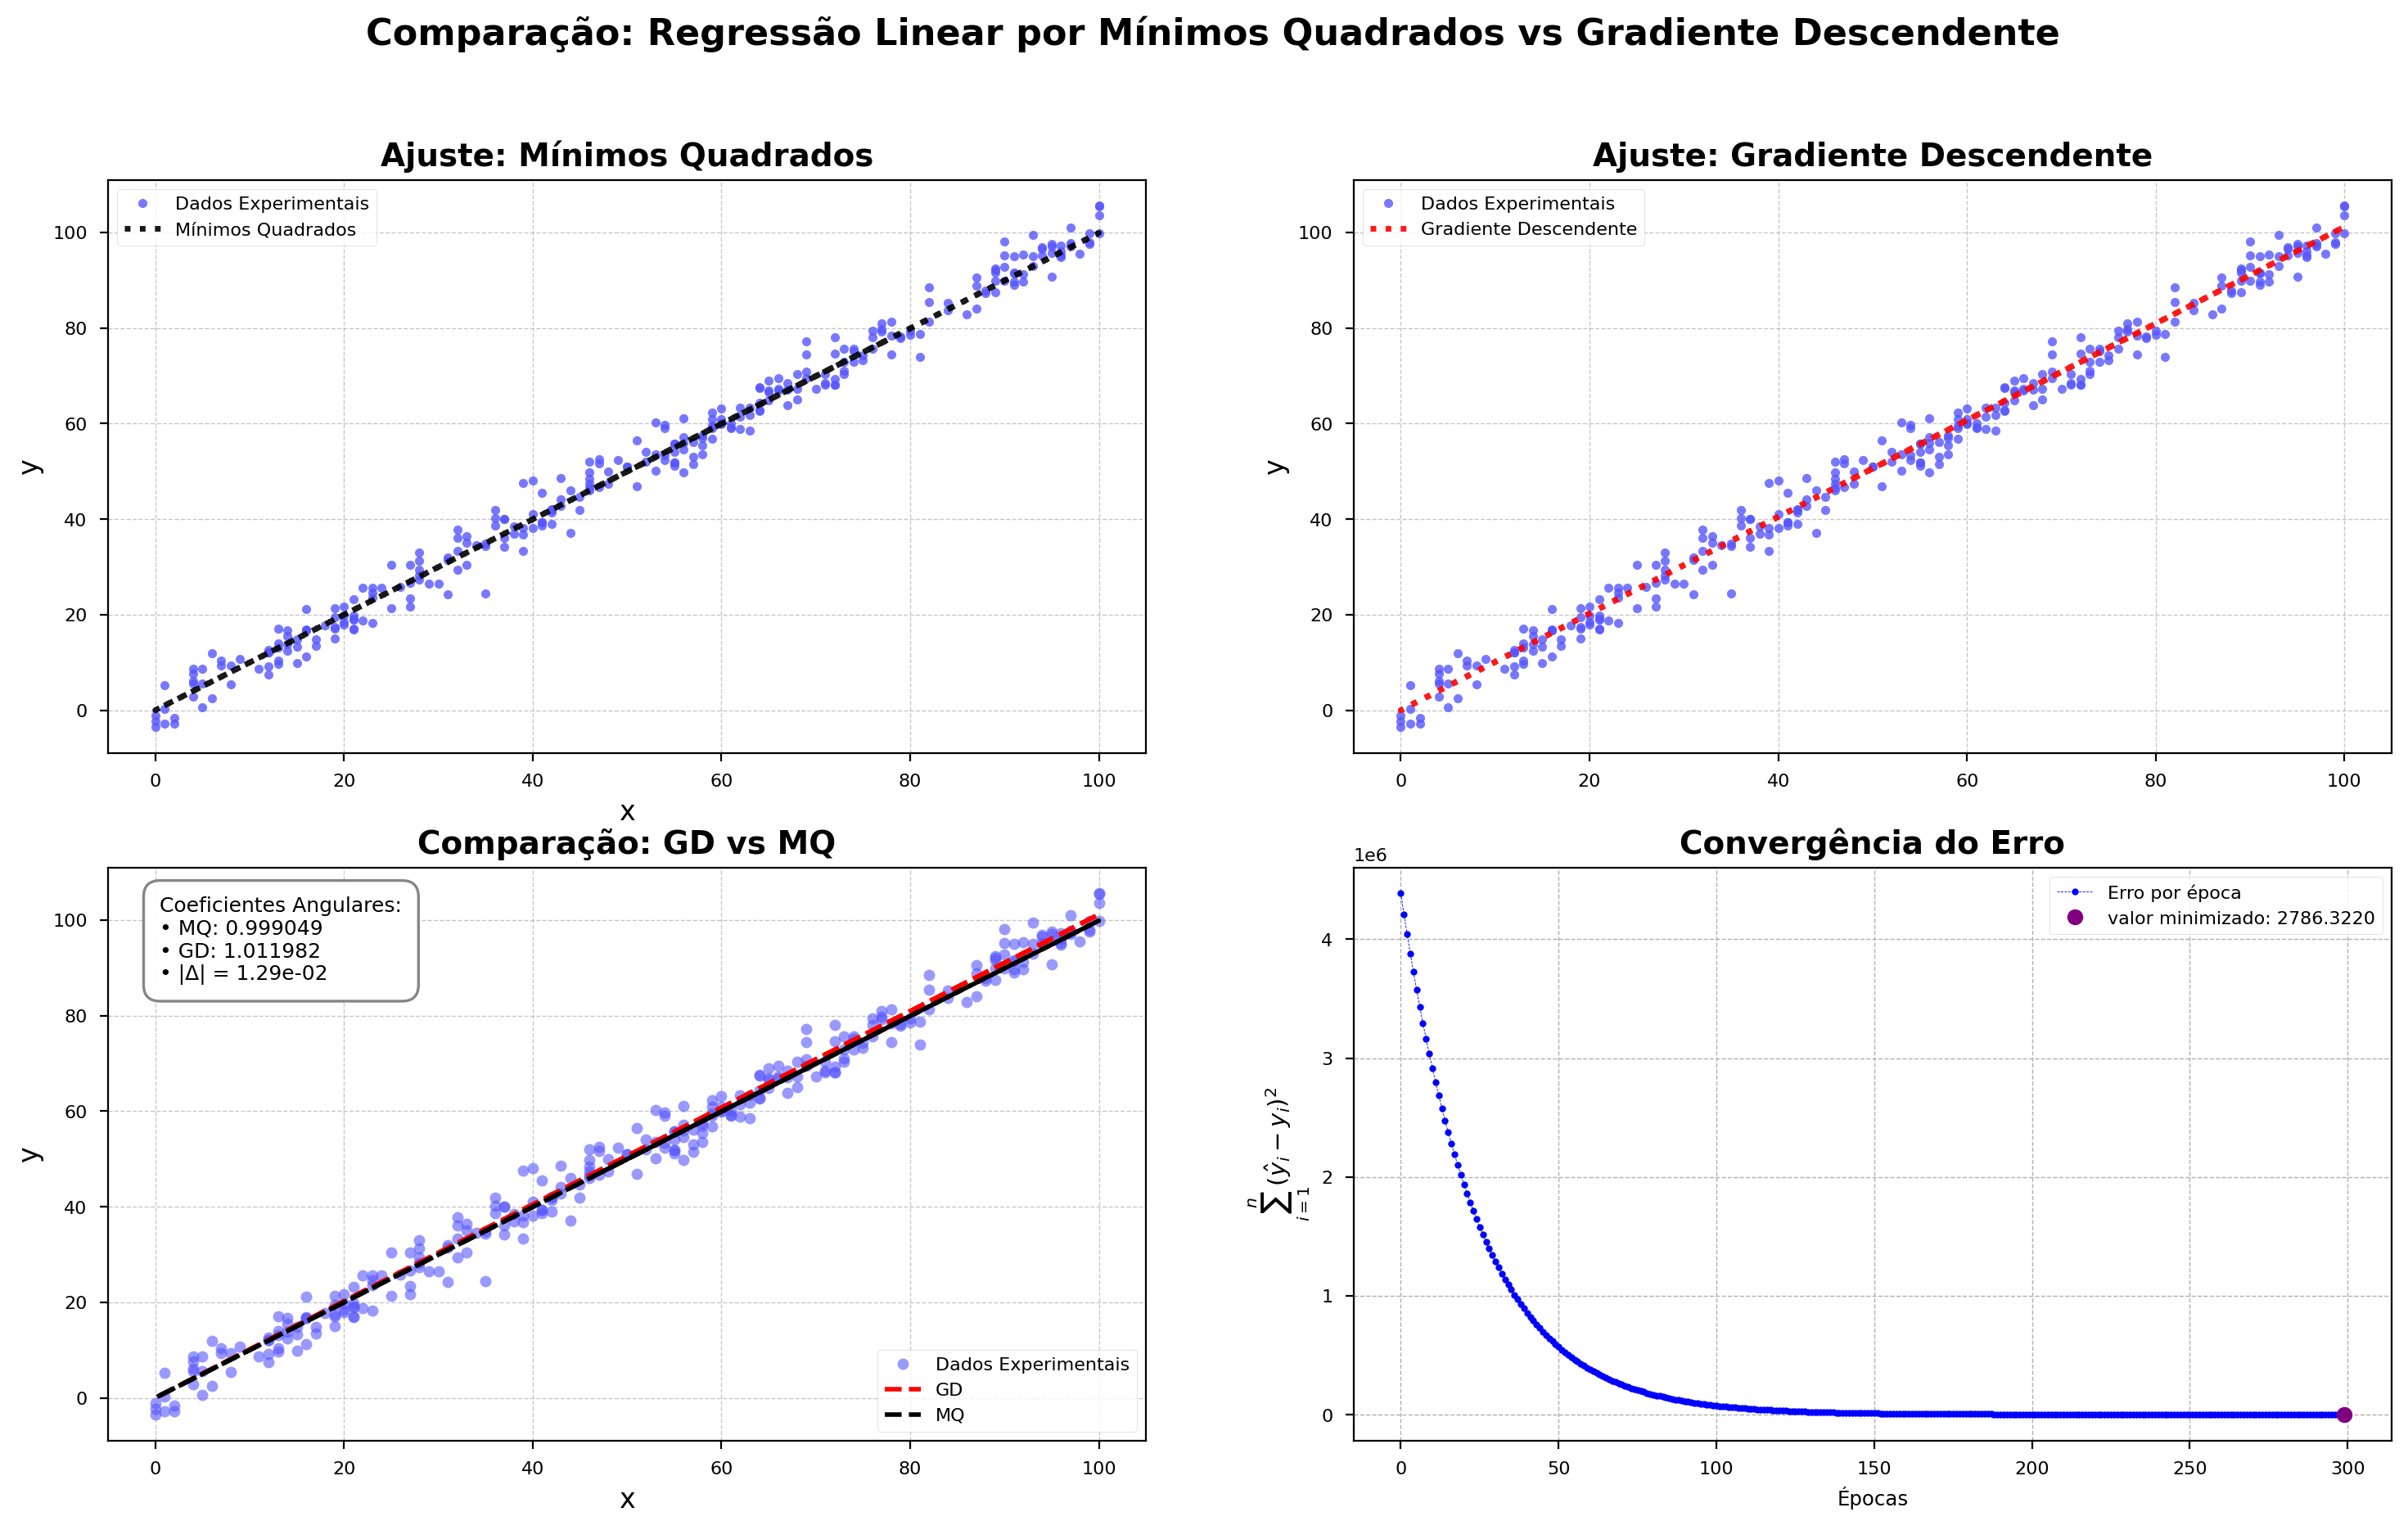

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(18,10), dpi=200)

colors = {
    'dados': "#5656FF",      # Azul mais elegante
    'gd': "#FF0000",         # Vermelho vibrante
    'mq': "#000000",         # Azul escuro/pretro elegante
    'erro': '#4361EE',       # Azul para curva de erro
    'ponto_final': '#7209B7' # Roxo para ponto final
}


# Mínimos Quadrados 
ax = axes[0][0]
ax.plot(x_test, y_test, color=colors['dados'], marker='o', linestyle='none', 
        alpha=0.8, label='Dados Experimentais', markersize=4)
ax.plot(x_test, mmq_pred, color=colors['mq'], linestyle='dotted', linewidth=2.5, 
        alpha=0.9, label='Mínimos Quadrados')
ax.set_title('Ajuste: Mínimos Quadrados', fontsize=14, fontweight='bold')
ax.set_ylabel('y', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.grid(axis='both', ls='--', lw=0.5, alpha=0.7)
ax.legend()

# Gradiente Descendente
ax = axes[0][1]
ax.plot(x_test, y_test, color=colors['dados'], marker='o', linestyle='none', 
        alpha=0.8, label='Dados Experimentais', markersize=4)
ax.plot(x_test, gd_pred, color=colors['gd'], linestyle='dotted', linewidth=2.5, 
        alpha=0.9, label='Gradiente Descendente')
ax.set_title('Ajuste: Gradiente Descendente', fontsize=14, fontweight='bold')
ax.set_ylabel('y', fontsize=12)
ax.grid(axis='both', ls='--', lw=0.5, alpha=0.7)
ax.legend()

# Comparação dos dois métodos
ax = axes[1][0]
ax.plot(x_test, y_test, color=colors['dados'], marker='o', linestyle='none', alpha=0.6, label='Dados Experimentais', markersize=5)
ax.plot(x_test, gd_pred, color=colors['gd'], linestyle='--', linewidth=2, alpha=1, label='GD')
ax.plot(x_test, mmq_pred, color=colors['mq'], linestyle='--', linewidth=2, alpha=1, label='MQ')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Comparação: GD vs MQ', fontsize=14, fontweight='bold')
ax.grid(axis='both', ls='--', lw=0.5, alpha=0.7)
ax.legend(loc='lower right')

eq_mq = f'y = {mq_params[0][0]:.4f}x'
eq_gd = f'y = {gd_params[0][0]:.4f}x'

# Posicionar texto no canto superior esquerdo
diff = gd_params[0][0] - mq_params[0][0]

# Posicionar texto no canto superior esquerdo
info_text = (
    f'Coeficientes Angulares:\n'
    f'• MQ: {mq_params[0][0]:.6f}\n'
    f'• GD: {gd_params[0][0]:.6f}\n'
    f'• |Δ| = {diff:.2e}'
)

ax.text(0.05, 0.95, info_text,
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.95,
                 edgecolor='gray', linewidth=1.2, pad=0.8))


ax = axes[1][1]

ax.plot(epoch_errors, 'o--',color='blue', markersize=3, lw=0.3, label='Erro por época')
ax.plot(len(epoch_errors) -1, epoch_errors[-1], 'o', color='purple', label=f'valor minimizado: {epoch_errors[-1]:.4f}', ms=7)
ax.set_xlabel('Épocas') 
ax.set_ylabel(r'$\sum_{i=1}^n (\hat y_i - y_i)^2$', fontsize=10.5)
ax.set_title('Convergência do Erro',  fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='both', ls='--', lw=0.5)

fig.suptitle('Comparação: Regressão Linear por Mínimos Quadrados vs Gradiente Descendente', 
             fontsize=16, fontweight='bold', y=0.98)

plt.show()